# Subpopulation Analysis of DNABERT-2 Embeddings

Hypothesis: the embedding UMAP looks "nice" because it captures Indica/Japonica
subpopulation structure, not within-population phenotypic variation.

This notebook tests three things:
1. **Infer subpopulations** via K-Means on the top SVD components of the embeddings.
2. **Stratified CV** — split folds so every fold contains proportional subpopulation
   representation, preventing the model from exploiting between-group phenotype offsets.
3. **PC removal** — project out the dominant axes (likely the population axes) before
   fitting models, forcing prediction from residual within-population variation.

All dimensionality reduction and PC removal is fit on training data only inside each fold.

In [1]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

EMB_PATH   = Path("/home/andrew.dickson/svar/embeddings/sativas413_embeddings.pt")
PHENO_PATH = Path("/home/andrew.dickson/rice_data/RiceDiversity_44K_Phenotypes_34traits_PLINK.txt")

## 1. Load & align data

In [2]:
data        = torch.load(EMB_PATH, map_location="cpu", weights_only=True)
embeddings  = data["embeddings"].float().numpy()   # (383, 768)
emb_samples = data["sample_ids"]

pheno_raw  = pd.read_csv(PHENO_PATH, sep="\t")
TRAIT_COLS = [c for c in pheno_raw.columns if c not in ("HybID", "NSFTVID")]

# Align on NSFTVID extracted from sample IDs like "081215-A05_1"
emb_nsftvid   = [int(s.rsplit("_", 1)[-1]) for s in emb_samples]
emb_id_to_idx = {nid: i for i, nid in enumerate(emb_nsftvid)}

pheno_raw["NSFTVID"] = pheno_raw["NSFTVID"].astype(int)
pheno_matched = (pheno_raw[pheno_raw["NSFTVID"].isin(emb_id_to_idx)]
                 .copy().reset_index(drop=True))

emb_row_order = [emb_id_to_idx[nid] for nid in pheno_matched["NSFTVID"]]
X = StandardScaler().fit_transform(embeddings[emb_row_order])

# Scale phenotypes per-trait, NaN-aware
Y_raw    = pheno_matched[TRAIT_COLS].values.astype(float)
Y_scaled = np.full_like(Y_raw, np.nan)
for j in range(Y_raw.shape[1]):
    col  = Y_raw[:, j]
    mask = ~np.isnan(col)
    if mask.sum() < 2:
        continue
    mu, std = col[mask].mean(), col[mask].std(ddof=0)
    Y_scaled[mask, j] = (col[mask] - mu) / (std if std > 0 else 1.0)

print(f"X: {X.shape}   Y: {Y_scaled.shape}")

X: (383, 768)   Y: (383, 36)


## 2. Infer subpopulations

Rice is typically divided into Indica, Tropical Japonica, Temperate Japonica, Aus, and Aromatic.
PC1 of the embeddings captures most of this structure (~41% of variance).

Rather than K-Means — which tends to find singleton outlier clusters that break
StratifiedKFold — we use **quartile binning on PC1**: four balanced groups of ~96 samples
each. This directly operationalises the hypothesis (PC1 ≈ population axis) and keeps
every group large enough for 8-fold stratified CV.

In [3]:
from sklearn.decomposition import TruncatedSVD

svd_pop = TruncatedSVD(n_components=10, random_state=42)
X_svd10 = svd_pop.fit_transform(X)

print("Variance explained per component:")
for i, v in enumerate(svd_pop.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f}")

# Quartile bins on PC1 — balanced groups, no singleton risk
N_POPS     = 4
pop_labels = pd.qcut(X_svd10[:, 0], q=N_POPS, labels=False).astype(int)

print("\nQuartile group sizes:")
for k in range(N_POPS):
    print(f"  Q{k+1}: {(pop_labels == k).sum()} samples")

Variance explained per component:
  PC1: 0.409
  PC2: 0.122
  PC3: 0.092
  PC4: 0.056
  PC5: 0.039
  PC6: 0.025
  PC7: 0.022
  PC8: 0.018
  PC9: 0.016
  PC10: 0.015

Quartile group sizes:
  Q1: 96 samples
  Q2: 96 samples
  Q3: 95 samples
  Q4: 96 samples


## 3. Visualise subpopulation structure

Left: UMAP coloured by inferred cluster. Right: the same layout coloured by a
representative quantitative trait. If the cluster boundaries align with the trait
gradient, between-population signal is dominating prediction.

/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


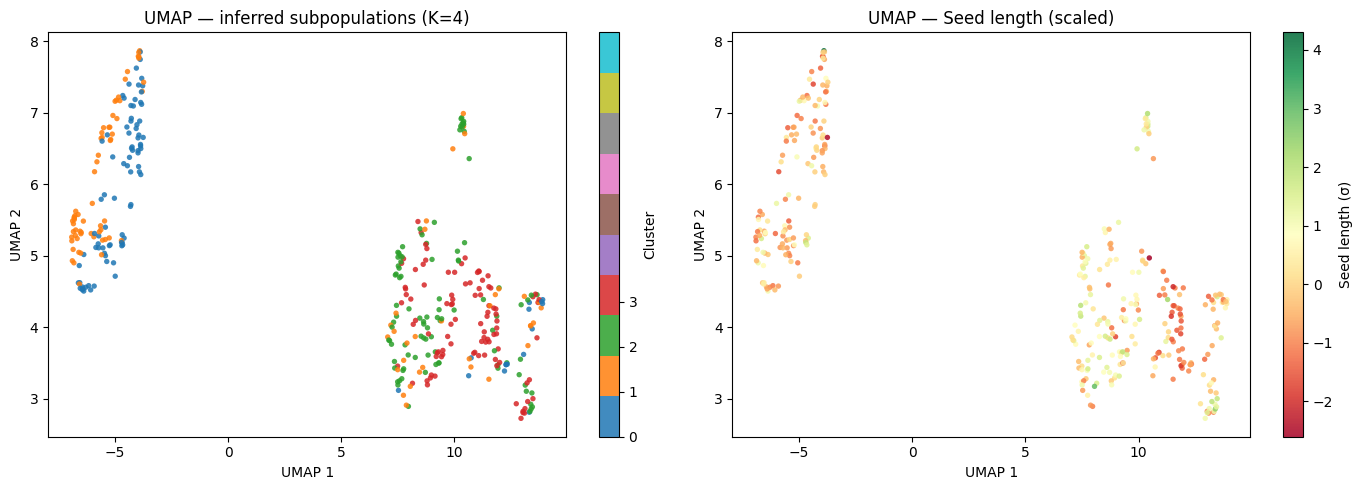

In [4]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.05)
coords  = reducer.fit_transform(X_svd10[:, :10])

SHOW_TRAIT = "Seed length"
ti         = TRAIT_COLS.index(SHOW_TRAIT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(coords[:, 0], coords[:, 1], c=pop_labels,
                       cmap="tab10", vmin=0, vmax=9, s=15, alpha=0.85, linewidths=0)
axes[0].set_title(f"UMAP — inferred subpopulations (K={N_POPS})")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")
plt.colorbar(sc0, ax=axes[0], ticks=range(N_POPS), label="Cluster")

sc1 = axes[1].scatter(coords[:, 0], coords[:, 1], c=Y_scaled[:, ti],
                       cmap="RdYlGn", s=15, alpha=0.85, linewidths=0)
axes[1].set_title(f"UMAP — {SHOW_TRAIT} (scaled)")
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
plt.colorbar(sc1, ax=axes[1], label=f"{SHOW_TRAIT} (σ)")

plt.tight_layout()
plt.show()

### 3a. Within-cluster vs between-cluster phenotype variance

If most of the phenotypic variance is between clusters, a model that simply
memorises cluster → mean will perform well on random CV but badly on stratified CV.

In [5]:
n_groups = len(np.unique(pop_labels))

print(f"{'Trait':<35} {'Between-pop R²':>16} {'Within-pop σ mean':>18}")
print("-" * 72)
for trait in TRAIT_COLS:
    ti   = TRAIT_COLS.index(trait)
    y_t  = Y_scaled[:, ti]
    mask = ~np.isnan(y_t)
    if mask.sum() < 30:
        continue
    y_sub = y_t[mask]
    p_sub = pop_labels[mask]

    cluster_means = np.array([y_sub[p_sub == k].mean() if (p_sub == k).sum() > 0 else 0
                               for k in range(n_groups)])
    y_pred_clust  = cluster_means[p_sub]
    between_r2    = 1 - np.sum((y_sub - y_pred_clust)**2) / np.sum((y_sub - y_sub.mean())**2)

    within_stds = [y_sub[p_sub == k].std() for k in range(n_groups) if (p_sub == k).sum() > 1]
    within_mean = np.mean(within_stds) if within_stds else np.nan

    print(f"{trait:<35} {between_r2:>16.3f} {within_mean:>18.3f}")

Trait                                 Between-pop R²  Within-pop σ mean
------------------------------------------------------------------------
Flowering time at Arkansas                     0.025              0.979
Flowering time at Faridpur                     0.004              0.994
Flowering time at Aberdeen                     0.019              0.984
FT ratio of Arkansas/Aberdeen                  0.079              0.957
FT ratio of Faridpur/Aberdeen                  0.033              0.967
Culm habit                                     0.253              0.849
Leaf pubescence                                0.077              0.898
Flag leaf length                               0.018              0.985
Flag leaf width                                0.071              0.952
Awn presence                                   0.014              0.989
Panicle number per plant                       0.327              0.818
Plant height                                   0.107           

## 4. Evaluation function

Every fold independently:
1. Optionally projects out the leading `remove_pcs` PCs (fit on training data only).
2. Reduces dimensionality with TruncatedSVD (fit on training data only).
3. Fits RidgeCV (alpha selected by inner CV).

`stratify_labels` switches between random KFold and StratifiedKFold.

In [6]:
from scipy.stats import pearsonr
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import r2_score

N_SVD = 50

def cv_eval(X_feat, y, models, *, n_splits=8, n_svd=N_SVD,
            remove_pcs=0, stratify_labels=None, random_state=42):
    if stratify_labels is not None:
        kf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        splits = list(kf.split(X_feat, stratify_labels))
    else:
        kf     = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        splits = list(kf.split(X_feat))

    results = {name: {"pearson_r": [], "r2": []} for name, _ in models}

    for train_idx, test_idx in splits:
        X_tr, X_te = X_feat[train_idx].copy(), X_feat[test_idx].copy()
        y_tr, y_te = y[train_idx], y[test_idx]

        # Remove leading PCs — fit direction on training data only
        if remove_pcs > 0:
            pc_svd = TruncatedSVD(n_components=remove_pcs, random_state=random_state)
            pc_svd.fit(X_tr)
            for pc in pc_svd.components_:
                X_tr -= np.outer(X_tr @ pc, pc)
                X_te -= np.outer(X_te @ pc, pc)

        # Dimensionality reduction — fit on training data only
        svd_fold = TruncatedSVD(n_components=n_svd, random_state=random_state)
        X_tr_r   = svd_fold.fit_transform(X_tr)
        X_te_r   = svd_fold.transform(X_te)

        for name, model in models:
            model.fit(X_tr_r, y_tr)
            y_pred = model.predict(X_te_r)
            r, _   = pearsonr(y_te, y_pred)
            results[name]["pearson_r"].append(r)
            results[name]["r2"].append(r2_score(y_te, y_pred))

    return {
        name: {
            "pearson_r":     float(np.mean(vals["pearson_r"])),
            "r2":            float(np.mean(vals["r2"])),
            "r2_std":        float(np.std(vals["r2"])),
            "pearson_r_std": float(np.std(vals["pearson_r"])),
        }
        for name, vals in results.items()
    }

## 5. Experiment

Six conditions: 3 preprocessing variants × 2 CV strategies.

In [7]:
MODELS = [("RidgeCV", RidgeCV(alphas=np.logspace(-3, 4, 50)))]

CONDITIONS = [
    # (label,                          remove_pcs, stratify)
    ("Random,    0 PCs removed",       0, False),
    ("Random,    PC1 removed",         1, False),
    ("Random,    PC1+2 removed",       2, False),
    ("Stratified, 0 PCs removed",      0, True),
    ("Stratified, PC1 removed",        1, True),
    ("Stratified, PC1+2 removed",      2, True),
]

EVAL_TRAITS = [
    "Alkali spreading value",
    "Amylose content",
    "Panicle number per plant",
    "Protein content",
    "Seed length",
    "Seed number per panicle",
]

all_rows = []
for cond_label, remove_pcs, stratify in CONDITIONS:
    print(f"Running: {cond_label} ...", end=" ", flush=True)
    for trait in EVAL_TRAITS:
        ti   = TRAIT_COLS.index(trait)
        y_t  = Y_scaled[:, ti]
        mask = ~np.isnan(y_t)
        if mask.sum() < 30:
            continue

        sl  = pop_labels[mask] if stratify else None
        res = cv_eval(X[mask], y_t[mask], MODELS,
                      remove_pcs=remove_pcs, stratify_labels=sl)

        for model_name, metrics in res.items():
            all_rows.append({
                "Condition":     cond_label,
                "Stratified":    stratify,
                "PCs removed":   remove_pcs,
                "Trait":         trait,
                "Pearson r":     round(metrics["pearson_r"], 4),
                "R²":            round(metrics["r2"],        4),
                "R² std":        round(metrics["r2_std"],    4),
                "Pearson r std": round(metrics["pearson_r_std"], 4),
                "n_samples":     int(mask.sum()),
            })
    print("done")

results_df = pd.DataFrame(all_rows)
print("\nAll conditions done.")

Running: Random,    0 PCs removed ... done
Running: Random,    PC1 removed ... done
Running: Random,    PC1+2 removed ... done
Running: Stratified, 0 PCs removed ... done
Running: Stratified, PC1 removed ... done
Running: Stratified, PC1+2 removed ... done

All conditions done.


In [8]:
pivot = results_df.pivot_table(
    index="Trait", columns="Condition", values="Pearson r", aggfunc="mean"
)
# Reorder columns by condition order
cond_order = [c for c, _, _ in CONDITIONS]
pivot = pivot[[c for c in cond_order if c in pivot.columns]]
pivot.round(3)

Condition,"Random, 0 PCs removed","Random, PC1 removed","Random, PC1+2 removed","Stratified, 0 PCs removed","Stratified, PC1 removed","Stratified, PC1+2 removed"
Trait,,,,,,
Alkali spreading value,0.391,0.374,0.320,0.368,0.355,0.288
Amylose content,0.591,0.586,0.389,0.581,0.579,0.393
Panicle number per plant,0.741,0.749,0.686,0.736,0.726,0.651
Protein content,0.380,0.374,0.359,0.378,0.374,0.345
Seed length,0.500,0.504,0.449,0.500,0.512,0.446
Seed number per panicle,0.327,0.346,0.289,0.310,0.324,0.249


### 5a. Stratification effect

Positive delta = stratified CV scores *lower* than random CV → the random CV was
being inflated by between-population signal. Negative delta = stratified CV scores
*higher* → the model actually generalises better when folds are balanced.

In [9]:
deltas = []
for pc in [0, 1, 2]:
    rand_label = f"Random,    {'0' if pc==0 else ('PC1' if pc==1 else 'PC1+2')} PCs removed"
    strat_label = f"Stratified, {'0' if pc==0 else ('PC1' if pc==1 else 'PC1+2')} PCs removed"
    for trait in EVAL_TRAITS:
        r_rand  = results_df[(results_df["Condition"] == rand_label)  &
                             (results_df["Trait"] == trait)]["Pearson r"]
        r_strat = results_df[(results_df["Condition"] == strat_label) &
                             (results_df["Trait"] == trait)]["Pearson r"]
        if len(r_rand) and len(r_strat):
            deltas.append({
                "Trait": trait,
                "PCs removed": pc,
                "Random r":     r_rand.values[0],
                "Stratified r": r_strat.values[0],
                "Δ (rand − strat)": r_rand.values[0] - r_strat.values[0],
            })

delta_df = pd.DataFrame(deltas)
print("Mean Δ (random − stratified) per PC-removal setting:")
print(delta_df.groupby("PCs removed")["Δ (rand − strat)"].mean().round(4))
print()
delta_df.pivot(index="Trait", columns="PCs removed", values="Δ (rand − strat)").round(3)

Mean Δ (random − stratified) per PC-removal setting:
PCs removed
0    0.0094
Name: Δ (rand − strat), dtype: float64



PCs removed,0
Trait,
Alkali spreading value,0.023
Amylose content,0.011
Panicle number per plant,0.004
Protein content,0.003
Seed length,-0.000
Seed number per panicle,0.016


## 6. Visualisation

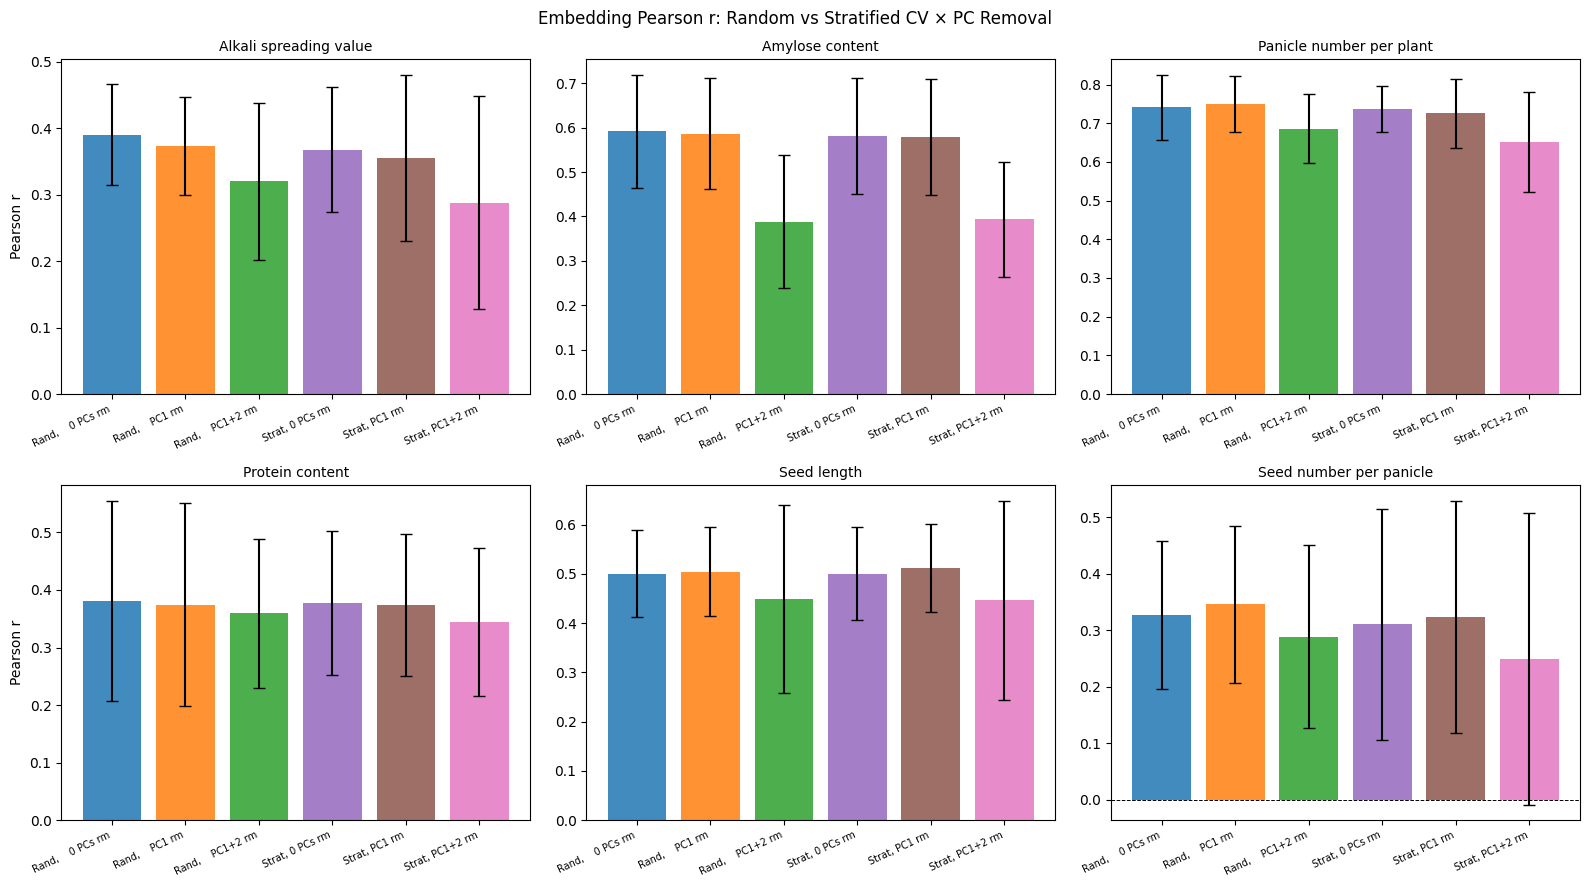

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.ravel()

cond_order  = [c for c, _, _ in CONDITIONS]
colors      = plt.cm.tab10(np.array([0, 0.1, 0.2, 0.4, 0.5, 0.6]))
short_labels = [c.replace("removed", "rm").replace("Stratified,", "Strat,")
                 .replace("Random,", "Rand,") for c in cond_order]

for i, trait in enumerate(EVAL_TRAITS):
    ax  = axes[i]
    sub = results_df[results_df["Trait"] == trait]

    means = []
    stds  = []
    for c in cond_order:
        row = sub[sub["Condition"] == c]
        means.append(row["Pearson r"].values[0]     if len(row) else np.nan)
        stds.append( row["Pearson r std"].values[0] if len(row) else np.nan)

    x = np.arange(len(cond_order))
    ax.bar(x, means, yerr=stds, capsize=4, color=colors, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(short_labels, fontsize=7, rotation=25, ha="right")
    ax.set_title(trait, fontsize=10)
    ax.set_ylabel("Pearson r" if i % 3 == 0 else "")

plt.suptitle("Embedding Pearson r: Random vs Stratified CV × PC Removal", fontsize=12)
plt.tight_layout()
plt.show()

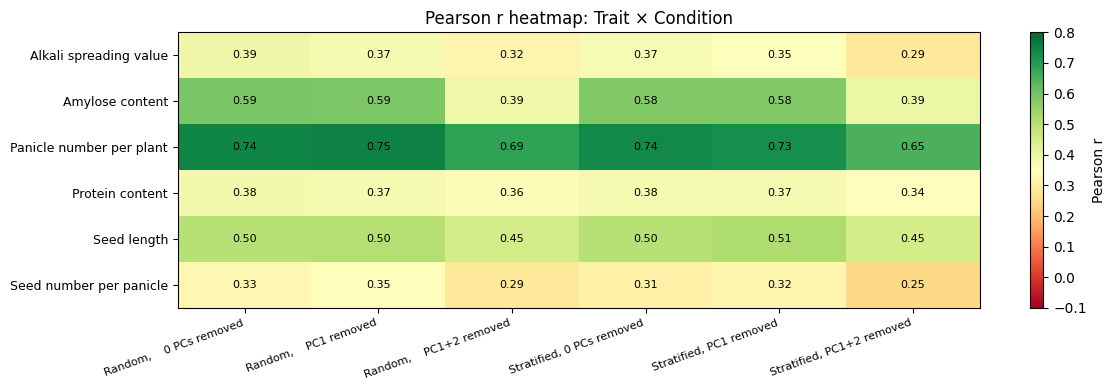

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
mat = pivot.values.astype(float)
im  = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=-0.1, vmax=0.8)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=8, rotation=20, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title("Pearson r heatmap: Trait × Condition")
plt.colorbar(im, ax=ax, label="Pearson r")

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if not np.isnan(mat[i, j]):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()